# Rainfall RNN LSTM Task 1 

**Title:** Rainfall Prediction Using Specialized RNN -> LSTM

**Student:** Mark William Gichora. J17/0963/2022

**Unit Name:** Neural Networks; CAT Individual Assignment

**Task:** Task 1 , Section 2 - Implementation of a machine learning algorithm (RNN) using one or more of TensorFlow, ScikitLearn and Kerras.

**Description:** 
This project implements a specialized form of Recurrent Neural Networks (RNN), Long Short-Term Memory (LSTM) models to predict rainfall patterns using historical climate data from Kenya (1991-2016). The model analyzes sequences in rainfall data to forecast future precipitation, utilizing deep learning techniques for time series forecasting.

In [45]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math
import warnings

warnings.filterwarnings("ignore")


In [46]:
df = pd.read_csv("../data/kenya-climate-data-1991-2016-rainfallmm.csv")
df.head()

,Year,Month Average,Rainfall - (MM)
0,1991,Jan Average,38.2847
1,1991,Feb Average,12.7492
2,1991,Mar Average,73.3656
3,1991,Apr Average,83.1350
4,1991,May Average,112.2750


# Data Cleaning and Preparation

In [47]:
month_names = df["Month Average"].astype(str).str.extract(r"([A-Za-z]+)", expand=False)
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + month_names + "-01")

df = df.sort_values("Date").reset_index(drop=True)
df = df.ffill()
df["Month"] = df["Date"].dt.month

df[["Date", "Month", "Rainfall - (MM)"]].head()

,Date,Month,Rainfall - (MM)
0,1991-01-01,1,38.2847
1,1991-02-01,2,12.7492
2,1991-03-01,3,73.3656
3,1991-04-01,4,83.1350
4,1991-05-01,5,112.2750


# Exploratory Data Analysis

Visualization helps identify:
- rainfall trends,
- seasonal patterns,
- and unusual fluctuations in the dataset.

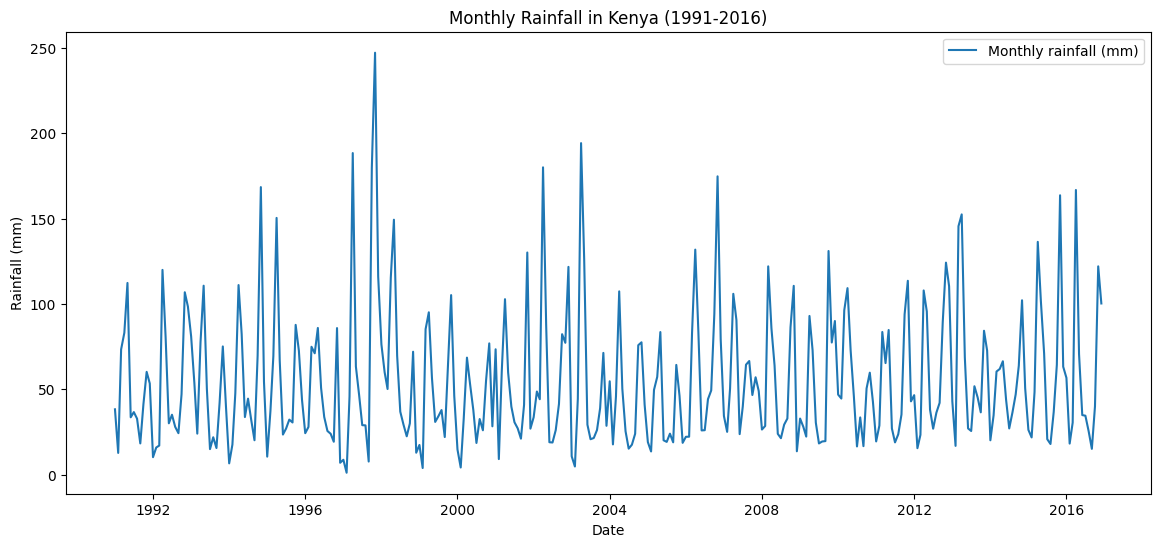

In [48]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Rainfall - (MM)"], label="Monthly rainfall (mm)")
plt.title("Monthly Rainfall in Kenya (1991-2016)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()

# Normalization via MinMaxScaler
Compress all rainfall values into a tight scale of 0 - 1, because neural networks do not handle large or highly varied numbers well.

In [49]:
data = df['Rainfall - (MM)'].values.reshape(-1, 1).astype(
    'float32'
)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)


# Create the sliding window

An LSTM cannot look at a single row of data and predict the future; it needs a sequence. I engineered the single column of rainfall into "look-back" windows.

Transforms a single column of time-series data into X (features) and y (target). I have used look_back=12 to give the model a full year of context to predict the next month.

In [50]:

def create_dataset(dataset, look_back=12):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        window = dataset[i:(i+look_back),0]
        X.append(window)

        target = dataset[i+look_back,0]
        y.append(target)
    return np.array(X), np.array(y)

In [51]:
look_back_months = 12
X,y = create_dataset(scaled_data,look_back_months)

In [52]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Train Test Split - 80/20

In [53]:
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (240, 12, 1)
Testing data shape: (60, 12, 1)


# Model Implementation - Building the LSTM

In [54]:
model = Sequential()
model.add(Input(shape=(look_back_months, 1)))
model.add(LSTM(units=50, activation='tanh'))
model.add(Dense(units=1))

model.compile(optimizer=Adam(
    learning_rate=0.001), 
    loss='mean_squared_error',
    metrics=['mean_squared_error'])

print("Model architecture built and compiled successfully.")
model.summary()

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=50,          # Go through the data 50 times
    batch_size=16,      # Update weights after every 16 sequences
    validation_data=(X_test, y_test),
    verbose=1           
)
print("Training complete.")


Model architecture built and compiled successfully.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0492 - mean_squared_error: 0.0492 - val_loss: 0.0271 - val_mean_squared_error: 0.0271
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0287 - mean_squared_error: 0.0287 - val_loss: 0.0274 - val_mean_squared_error: 0.0274
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0272 - mean_squared_error: 0.0272 - val_loss: 0.0277 - val_mean_squared_error: 0.0277
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0271 - mean_squared_error: 0.0271 - val_loss: 0.0272 - val_mean_squared_error: 0.0272
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0269 - mean_squared_error: 0.0269 - val_loss: 0.0272 - val_mean_squared_error: 0.0272
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0269 - mean_squared_error: 0.0269 - val_loss: 0.0268 - val_mean_squared_error: 0.0268
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0267 - mean_squared_error: 0.0267 - 

# Evaluation and Visualization

In [55]:
predicted_scaled = model.predict(X_test)

predicted_rainfall = scaler.inverse_transform(predicted_scaled)
actual_rainfall = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = math.sqrt(mean_squared_error(actual_rainfall, predicted_rainfall))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} mm")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step
Root Mean Squared Error (RMSE): 32.04 mm


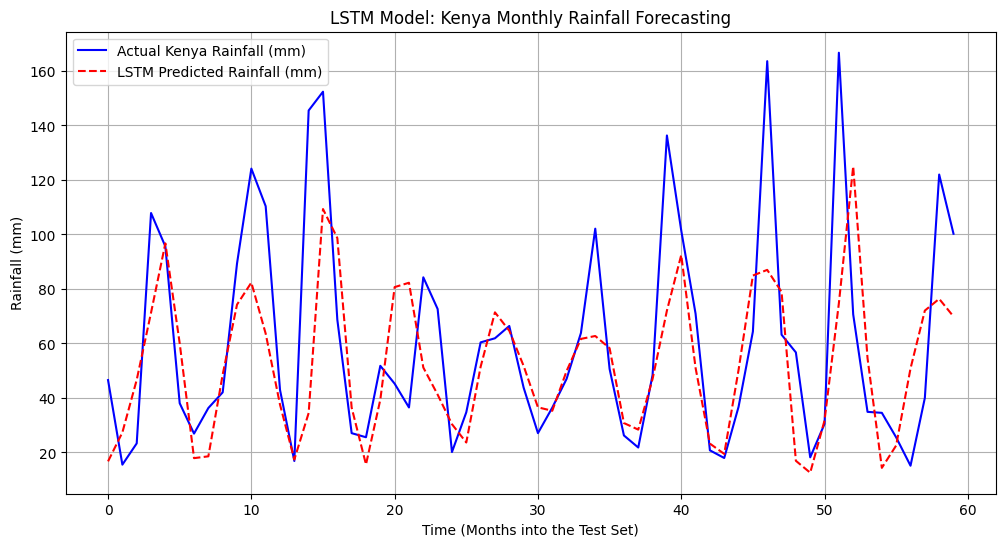

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(actual_rainfall, color='blue', label='Actual Kenya Rainfall (mm)')
plt.plot(predicted_rainfall, color='red', linestyle='dashed', label='LSTM Predicted Rainfall (mm)')

plt.title('LSTM Model: Kenya Monthly Rainfall Forecasting')
plt.xlabel('Time (Months into the Test Set)')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

# Example Prediction
Predcting the next month after the last month in the dataset

In [57]:
# --- PREDICTING THE UNKNOWN FUTURE ---

last_window = scaled_data[-look_back_months:]


last_window_reshaped = np.reshape(last_window, (1, look_back_months, 1))

future_prediction_scaled = model.predict(last_window_reshaped)

future_prediction_mm = scaler.inverse_transform(future_prediction_scaled)

print("--------------------------------------------------")
print(f"Based on the last {look_back_months} months of weather data,")
print(f"the LSTM predicts next month's rainfall will be: {future_prediction_mm[0][0]:.2f} mm")
print("--------------------------------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
--------------------------------------------------
Based on the last 12 months of weather data,
the LSTM predicts next month's rainfall will be: 36.23 mm
--------------------------------------------------
